In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [8]:
data = pd.read_csv('Downloads/fraudTest.csv')


In [10]:
# Display basic info
print("Dataset Shape:", data.shape)
print("\nColumn Names:\n", data.columns)
print("\nMissing Values:\n", data.isnull().sum())
print("\nFirst 5 Rows:\n", data.head())

Dataset Shape: (555719, 23)

Column Names:
 Index(['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant', 'category',
       'amt', 'first', 'last', 'gender', 'street', 'city', 'state', 'zip',
       'lat', 'long', 'city_pop', 'job', 'dob', 'trans_num', 'unix_time',
       'merch_lat', 'merch_long', 'is_fraud'],
      dtype='object')

Missing Values:
 Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

First

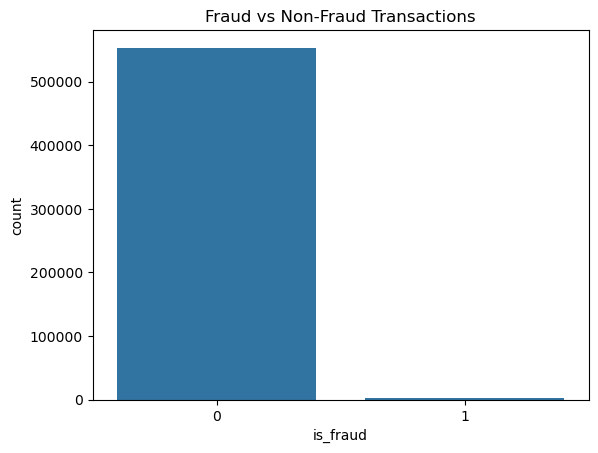

In [12]:
# Checking class balance
sns.countplot(x='is_fraud', data=data)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

In [14]:
# Dropping irrelevant columns (if needed)
data = data.drop(columns=['trans_date_trans_time', 'merchant', 'first', 'last', 'street', 'city', 'state', 'dob', 'trans_num'])


In [16]:
# Encoding categorical variables
label_enc = LabelEncoder()
data['category'] = label_enc.fit_transform(data['category'])

In [56]:
# Defining features and target
X = data.drop(columns=['is_fraud'])
y = data['is_fraud']

# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Standardizing numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize models
decision_tree = DecisionTreeClassifier()
log_reg = LogisticRegression()
ann = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42)

# Train models
decision_tree.fit(X_train, y_train)
log_reg.fit(X_train, y_train)
ann.fit(X_train, y_train)


MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=100, random_state=42)

In [58]:
# Predictions
dt_pred = decision_tree.predict(X_test)
lr_pred = log_reg.predict(X_test)
ann_pred = ann.predict(X_test)

In [60]:
# Evaluation
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name} Model Evaluation")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_true, y_pred))
    print("Classification Report:\n", classification_report(y_true, y_pred))

evaluate_model("Decision Tree", y_test, dt_pred)
evaluate_model("Logistic Regression", y_test, lr_pred)
evaluate_model("Artificial Neural Network", y_test, ann_pred)



Decision Tree Model Evaluation
Accuracy: 0.9970398761966458
Confusion Matrix:
 [[110534    181]
 [   148    281]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.61      0.66      0.63       429

    accuracy                           1.00    111144
   macro avg       0.80      0.83      0.81    111144
weighted avg       1.00      1.00      1.00    111144


Logistic Regression Model Evaluation
Accuracy: 0.9959062117613187
Confusion Matrix:
 [[110689     26]
 [   429      0]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00    110715
           1       0.00      0.00      0.00       429

    accuracy                           1.00    111144
   macro avg       0.50      0.50      0.50    111144
weighted avg       0.99      1.00      0.99    111144


Artificial Neural Network Model Evaluation
Accuracy: 0.997804